# Aula 08 – Análise de Dados com Matplotlib

Nesta aula vamos analisar dados e gerar insights utilizando gráficos.

## 1. Importando bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carregando os dados

In [2]:
caminho_arquivo = r"C:\Users\Joao.Maria\Documents\curso-python_joao_pedro\Base\Base de Vendas Dez, Jan, Fev.csv"

base_venda = pd.read_csv(caminho_arquivo, sep=";")

In [3]:

base_venda['DATAEMISSAO'] = pd.to_datetime(base_venda['DATAEMISSAO'])


In [4]:
base_venda.columns

Index(['DATAEMISSAO', 'CODIGOCLIENTE', 'DESCRICAOCLIENTE',
       'CODIGOGRUPOPRODUTO', 'DESCRICAOGRUPOPRODUTO', 'CODIGOPRODUTO',
       'NOMEPRODUTO', 'TIPOFATURAMENTO', 'DESCRICAOTIPOFATURAMENTO', 'VOLUME',
       'VALORLIQUIDO', 'MES'],
      dtype='str')

## 2. Evolução de Vendas no Tempo

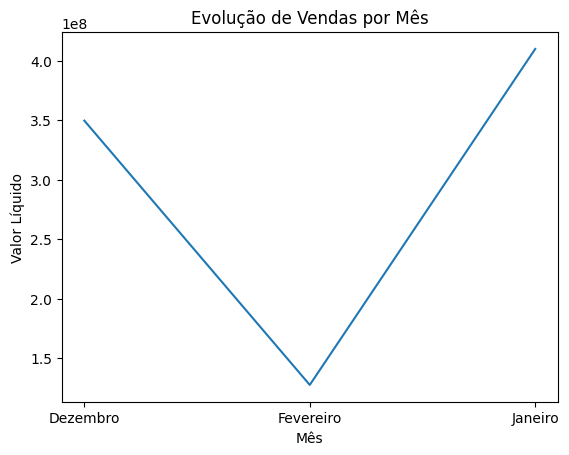

In [7]:
base_venda_tempo = (
    base_venda.groupby('MES')['VALORLIQUIDO']
      .sum()
      .reset_index()
)

plt.figure()
plt.plot(base_venda_tempo['MES'], base_venda_tempo['VALORLIQUIDO'])
plt.title('Evolução de Vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Valor Líquido')
plt.show()


## 3. Top 10 Clientes

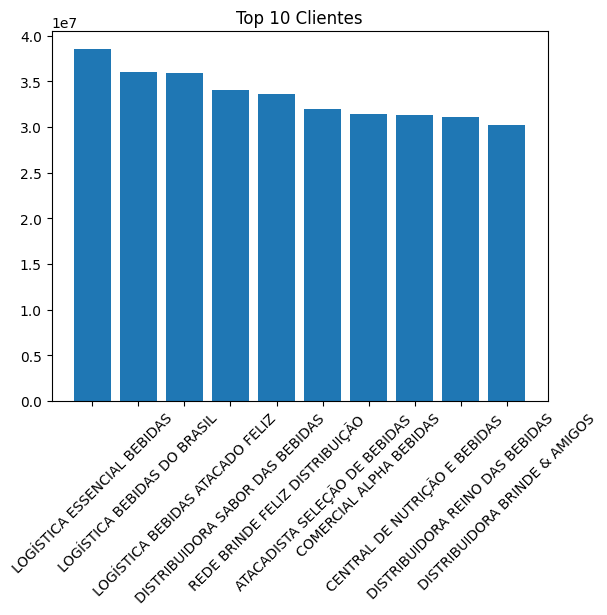

In [8]:
base_venda_cliente = (
    base_venda.groupby('DESCRICAOCLIENTE')['VALORLIQUIDO']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure()
plt.bar(base_venda_cliente['DESCRICAOCLIENTE'], base_venda_cliente['VALORLIQUIDO'])
plt.title('Top 10 Clientes')
plt.xticks(rotation=45)
plt.show()


## 4. Top 10 Produtos

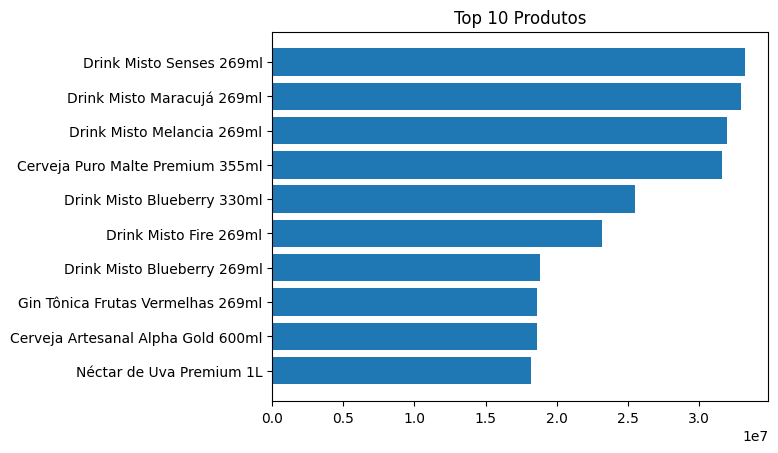

In [9]:
base_venda_produto = (
    base_venda.groupby('NOMEPRODUTO')['VALORLIQUIDO']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure()
plt.barh(base_venda_produto['NOMEPRODUTO'], base_venda_produto['VALORLIQUIDO'])
plt.title('Top 10 Produtos')
plt.gca().invert_yaxis()
plt.show()


## 5. Volume vs Receita

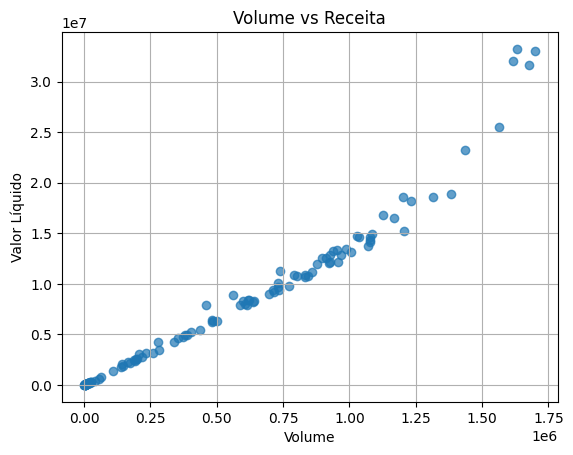

In [8]:
base_venda_relacao = (
    base_venda.groupby('NOMEPRODUTO')[['VOLUME', 'VALORLIQUIDO']]
      .sum()
      .reset_index()
)

plt.figure()
plt.scatter(base_venda_relacao['VOLUME'], base_venda_relacao['VALORLIQUIDO'], alpha=0.7)
plt.title('Volume vs Receita')
plt.xlabel('Volume')
plt.ylabel('Valor Líquido')
plt.grid(True)
plt.show()


## 6. Histograma (Distribuição de Receita)

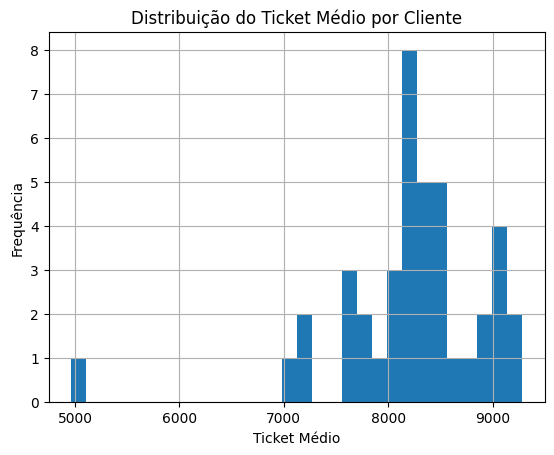

In [18]:
ticket_medio_cliente = (
    base_venda.groupby('DESCRICAOCLIENTE')['VALORLIQUIDO']
    .mean()
)

plt.figure()
plt.hist(ticket_medio_cliente, bins=30)
plt.title('Distribuição do Ticket Médio por Cliente')
plt.xlabel('Ticket Médio')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

## 7. Gráfico de Pizza (Participação por Grupo)

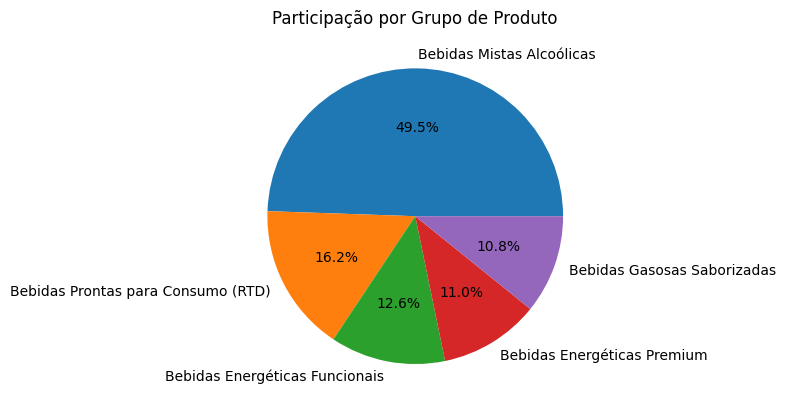

In [19]:
base_venda_grupo = (
    base_venda.groupby('DESCRICAOGRUPOPRODUTO')['VALORLIQUIDO']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

plt.figure()
plt.pie(base_venda_grupo, labels=base_venda_grupo.index, autopct='%1.1f%%')
plt.title('Participação por Grupo de Produto')
plt.show()